### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [98]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [10]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [25]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_enc,Has_Partner,Days_As_Customer
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,2,0,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,3,11,0,2,0,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,3,11,0,2,1,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,3,11,0,2,1,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,3,11,0,4,1,161


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [13]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Income    24
dtype: int64


Пропущенні значення у нас має тільки колонка Income, і лише 24 значення у ній

In [12]:
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

Виглядає що дані +- симетрично розподілені, і медіана і середнє арифметине між собою сильно не відрізняються, тому не буде суттєвої різниці що з цих значень я виберу. але обираю просто медіану

In [14]:
df['Income'] = df['Income'].fillna(df['Income'].median())

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [17]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

колонку з освітою я просто пронумерую за ступнем освіти

In [15]:
education_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
df['Education_enc'] = df['Education'].map(education_order)

In [19]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

з цієї колонки я створю просто бінарну колонку де 1 це людина має пару, 0 - не має

In [21]:
df['Has_Partner'] = df['Marital_Status'].apply(
    lambda x: 1 if x in ['Married', 'Together'] else 0
)

колонку з датою я б зробила числову колонку з кількість днів з моменту реєстрації

In [23]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()  # беру найпізнішу дату як точку відліку
df['Days_As_Customer'] = (reference_date - df['Dt_Customer']).dt.days

In [24]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_enc,Has_Partner,Days_As_Customer
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,2,0,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,3,11,0,2,0,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,3,11,0,2,1,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,3,11,0,2,1,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,3,11,0,4,1,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,3,11,0,2,1,381
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,1,0,0,3,11,0,4,1,19
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,0,0,0,3,11,0,2,0,155
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,3,11,0,3,1,156


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [27]:
cols_to_drop = ['ID', 'Education', 'Marital_Status', 'Dt_Customer']
X = df.drop(columns=cols_to_drop)

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

In [30]:
df['Cluster'] = labels
print(df['Cluster'].value_counts().sort_index())

sil = silhouette_score(X, labels)
print(sil)

Cluster
0    852
1    607
2    781
Name: count, dtype: int64
0.5378509726139659


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

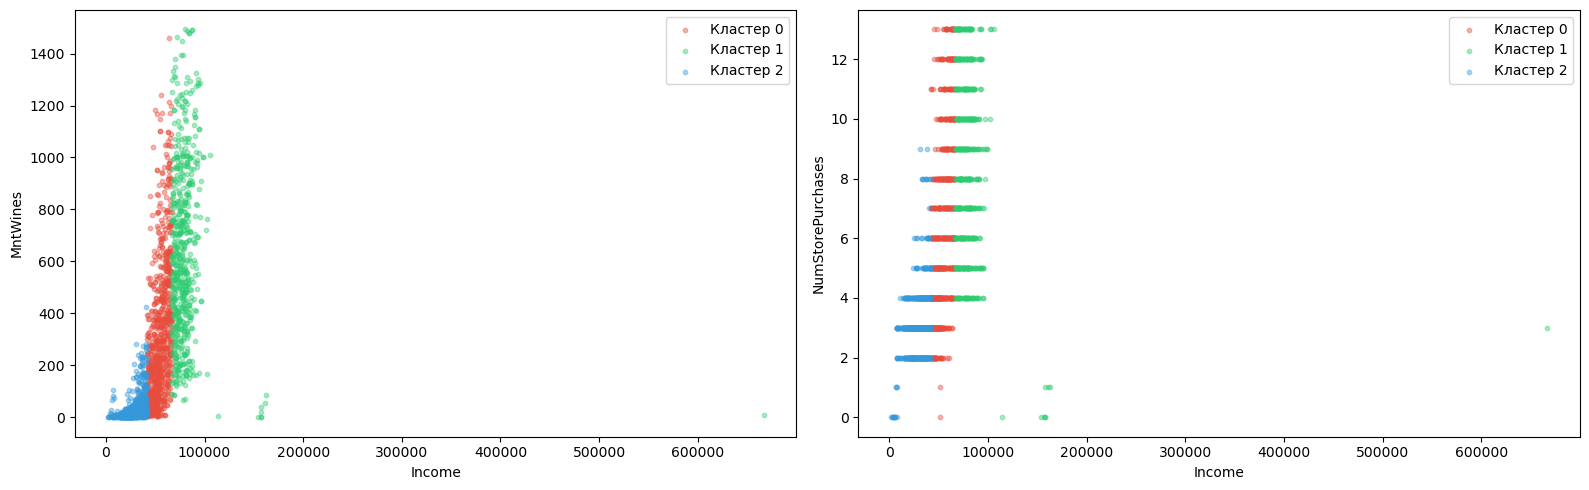

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

for cluster_id in range(3):
    mask = df['Cluster'] == cluster_id
    axes[0].scatter(
        df.loc[mask, 'Income'],
        df.loc[mask, 'MntWines'],
        alpha=0.4, s=10,
        color=colors[cluster_id],
        label=f'Кластер {cluster_id}'
    )
    axes[1].scatter(
        df.loc[mask, 'Income'],
        df.loc[mask, 'NumStorePurchases'],
        alpha=0.4, s=10,
        color=colors[cluster_id],
        label=f'Кластер {cluster_id}'
    )

axes[0].set_xlabel('Income'); axes[0].set_ylabel('MntWines'); axes[0].legend()

axes[1].set_xlabel('Income'); axes[1].set_ylabel('NumStorePurchases'); axes[1].legend()

plt.tight_layout()
plt.show()

Кластери мають сенс. Кластер 1: клієнти з найвищим доходом, мають найвищі витрати на вино в середньому та найбільшу кількість покупок. кластер нуль: нижчий дохід, уже менші витрати на вино та нижча кість покупок, а кластер 2 це клієнти з найнижчим рівнем доходу, найменшими витратами на вино та найменша кість покупок

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

df['Cluster_Scaled'] = labels_scaled

sil_scaled = silhouette_score(X_scaled, labels_scaled)

print(f'Без масштабування: {sil:.4f}')
print(f'З масштабуванням:  {sil_scaled:.4f}')

Без масштабування: 0.5379
З масштабуванням:  0.1591


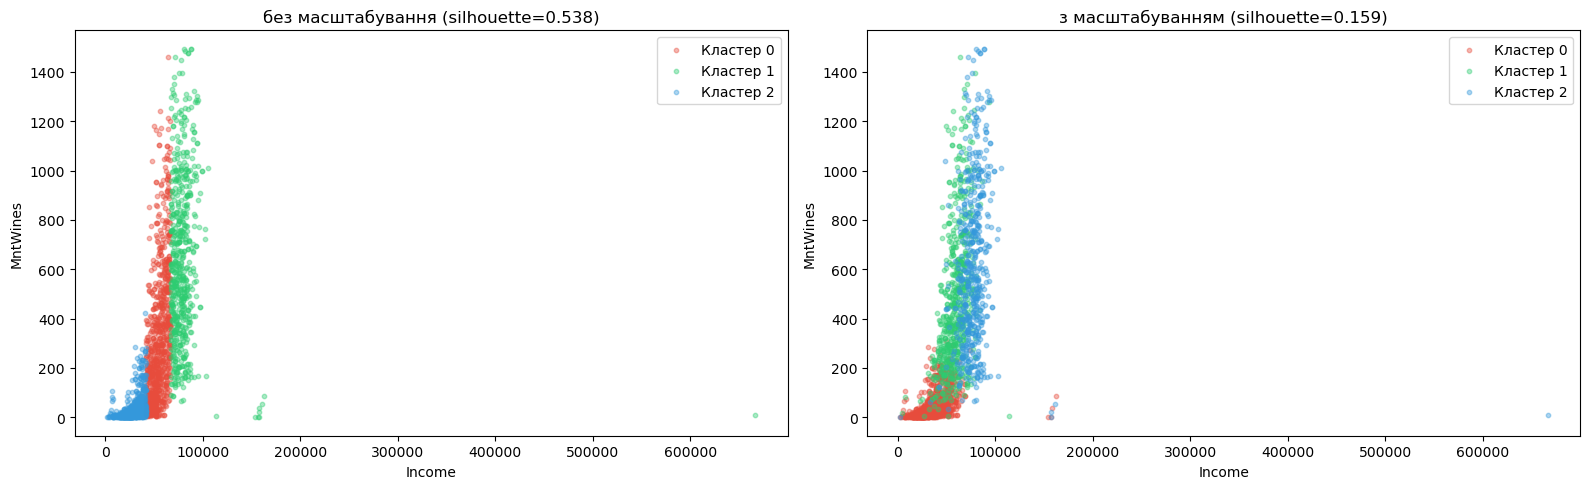

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

for cluster_id in range(3):
    mask0 = df['Cluster'] == cluster_id
    axes[0].scatter(df.loc[mask0, 'Income'], df.loc[mask0, 'MntWines'],
                    alpha=0.4, s=10, color=colors[cluster_id], label=f'Кластер {cluster_id}')

    mask1 = df['Cluster_Scaled'] == cluster_id
    axes[1].scatter(df.loc[mask1, 'Income'], df.loc[mask1, 'MntWines'],
                    alpha=0.4, s=10, color=colors[cluster_id], label=f'Кластер {cluster_id}')

axes[0].set_title(f'без масштабування (silhouette={sil:.3f})')
axes[1].set_title(f'з масштабуванням (silhouette={sil_scaled:.3f})')
for ax in axes:
    ax.set_xlabel('Income'); ax.set_ylabel('MntWines'); ax.legend()

plt.tight_layout()
plt.show()

силует без масштабування був 0.53, але це оманливо: KMeans кластеризував майже виключно за Income, бо ця ознака в десятках тисяч і просто перевищувала всі інші. після масштабування всі ознаки на одному масштабі, тому алгоритм враховує їх рівноцінно. на правому графіку видно, що розбивка стала менш чіткою по доходу, зате більш змістовною загалом

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

я їх просто видалю, бо їх небагато

In [79]:
df_clean = df[df['Income'] < 110000].copy().reset_index(drop=True)
X_clean = X[df['Income'] < 110000].copy().reset_index(drop=True)

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [84]:
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)

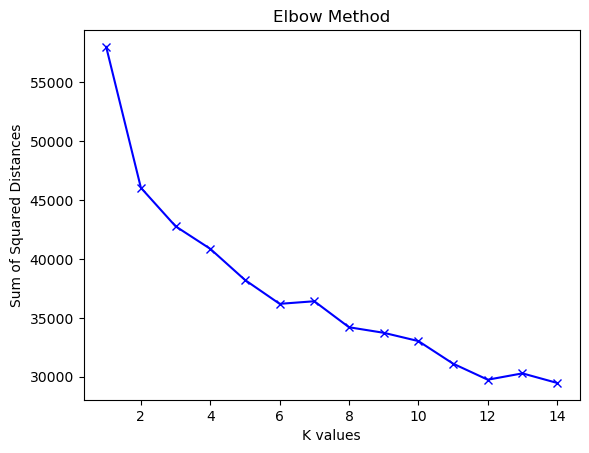

In [85]:
K = range(1,15)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_clean_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [92]:
kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels_opt = kmeans_opt.fit_predict(X_clean_scaled)

df_clean['Cluster_Opt'] = labels_opt

sil_opt = silhouette_score(X_clean_scaled, labels_opt)
print(f'Silhouette (k=3, масштаб, без викидів): {sil_opt:.4f}')
print(df_clean['Cluster_Opt'].value_counts().sort_index())

Silhouette (k=3, масштаб, без викидів): 0.1605
Cluster_Opt
0     549
1     660
2    1022
Name: count, dtype: int64


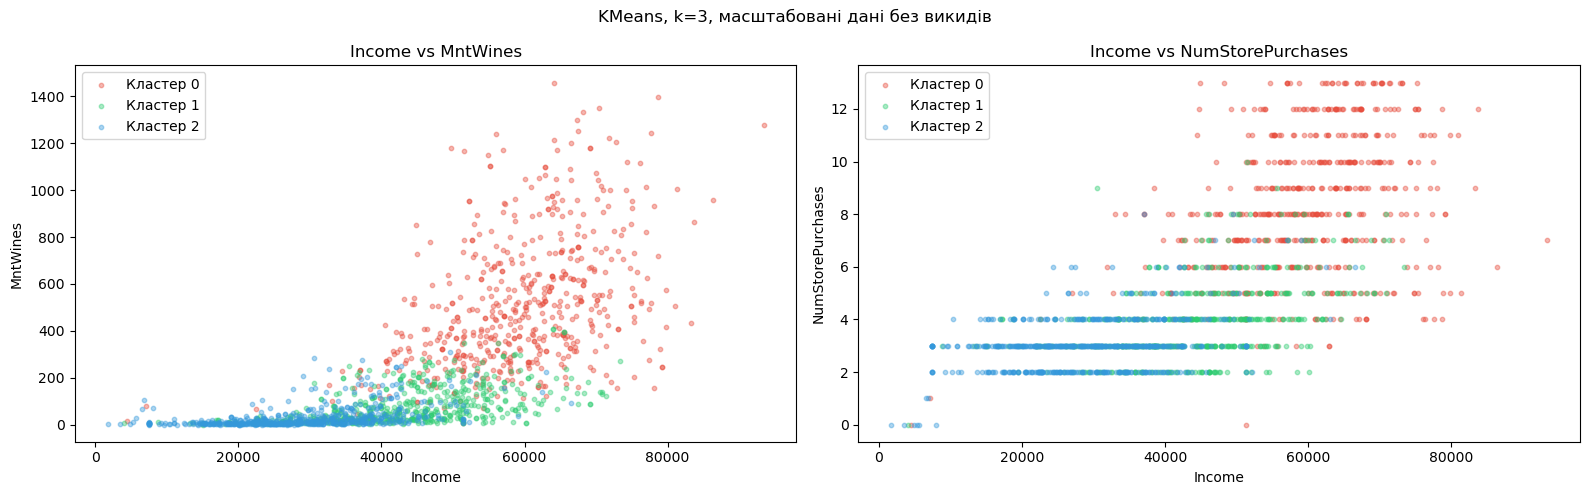

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db', 3: '#f39c12'}

for cluster_id in range(3):
    mask = df_clean['Cluster_Opt'] == cluster_id
    axes[0].scatter(df_clean.loc[mask, 'Income'], df_clean.loc[mask, 'MntWines'],
                    alpha=0.4, s=10, color=colors[cluster_id], label=f'Кластер {cluster_id}')
    axes[1].scatter(df_clean.loc[mask, 'Income'], df_clean.loc[mask, 'NumStorePurchases'],
                    alpha=0.4, s=10, color=colors[cluster_id], label=f'Кластер {cluster_id}')

axes[0].set_xlabel('Income'); axes[0].set_ylabel('MntWines')
axes[0].set_title('Income vs MntWines'); axes[0].legend()
axes[1].set_xlabel('Income'); axes[1].set_ylabel('NumStorePurchases')
axes[1].set_title('Income vs NumStorePurchases'); axes[1].legend()

plt.suptitle(f'KMeans, k=3, масштабовані дані без викидів')
plt.tight_layout()
plt.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

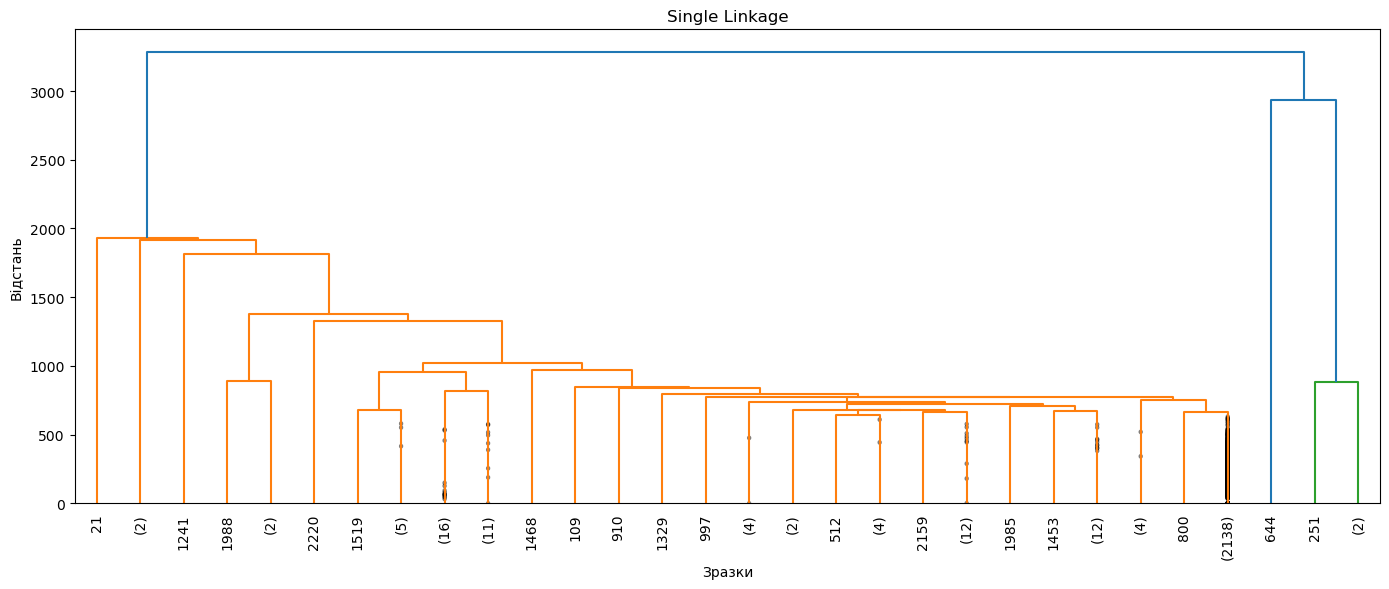

In [95]:
Z = linkage(X_clean, method='single')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Single Linkage')
plt.xlabel('Зразки')
plt.ylabel('Відстань')
plt.tight_layout()
plt.show()

In [96]:
labels_single2 = fcluster(Z, t=2, criterion='maxclust')
labels_single3 = fcluster(Z, t=3, criterion='maxclust')

sil_single2 = silhouette_score(X_clean, labels_single2)
sil_single3 = silhouette_score(X_clean, labels_single3)

print(f'Silhouette (single linkage, 2 кластери): {sil_single2:.4f}')
print(f'Silhouette (single linkage, 3 кластери): {sil_single3:.4f}')
print('\nРозподіл (2 кластери):', dict(pd.Series(labels_single2).value_counts()))
print('Розподіл (3 кластери):', dict(pd.Series(labels_single3).value_counts()))

Silhouette (single linkage, 2 кластери): 0.4510
Silhouette (single linkage, 3 кластери): 0.4404

Розподіл (2 кластери): {1: 2227, 2: 4}
Розподіл (3 кластери): {1: 2227, 2: 3, 3: 1}


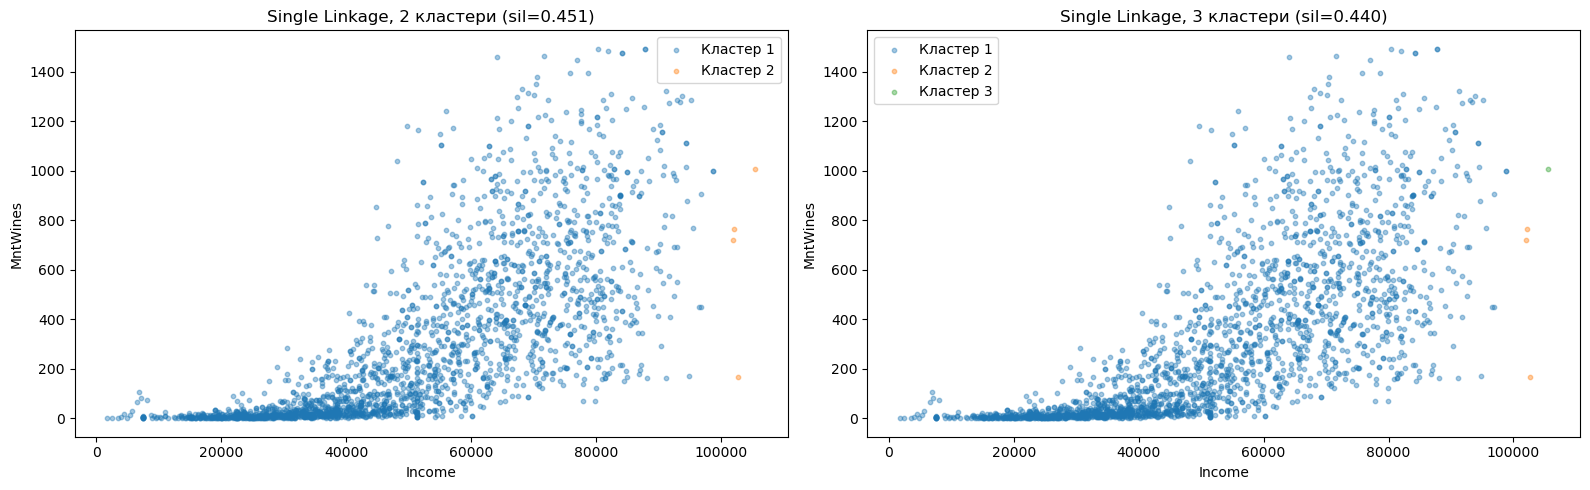

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cid in set(labels_single2):
    mask = labels_single2 == cid
    axes[0].scatter(X_clean.loc[mask, 'Income'], X_clean.loc[mask, 'MntWines'],
                    alpha=0.4, s=10, label=f'Кластер {cid}')

for cid in set(labels_single3):
    mask = labels_single3 == cid
    axes[1].scatter(X_clean.loc[mask, 'Income'], X_clean.loc[mask, 'MntWines'],
                    alpha=0.4, s=10, label=f'Кластер {cid}')

axes[0].set_title(f'Single Linkage, 2 кластери (sil={sil_single2:.3f})')
axes[1].set_title(f'Single Linkage, 3 кластери (sil={sil_single3:.3f})')
for ax in axes:
    ax.set_xlabel('Income'); ax.set_ylabel('MntWines'); ax.legend()

plt.tight_layout()
plt.show()

Silhouette для 2 і 3 кластерів виглядає непогано, але це оманливо. з розподілу видно що single linkage просто відокремив кілька викидів в окремі кластери, а всіх інших кинув в один великий. жодна з кластеризацій не є вдалою.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте метрику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [102]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_ward = agg.fit_predict(X_clean_scaled)

df_clean['Cluster_Ward'] = labels_ward

sil_ward = silhouette_score(X_clean_scaled, labels_ward)
print(f'Silhouette: {sil_ward:.4f}')
print(pd.Series(labels_ward).value_counts().sort_index())

Silhouette: 0.1327
0     527
1    1109
2     595
Name: count, dtype: int64


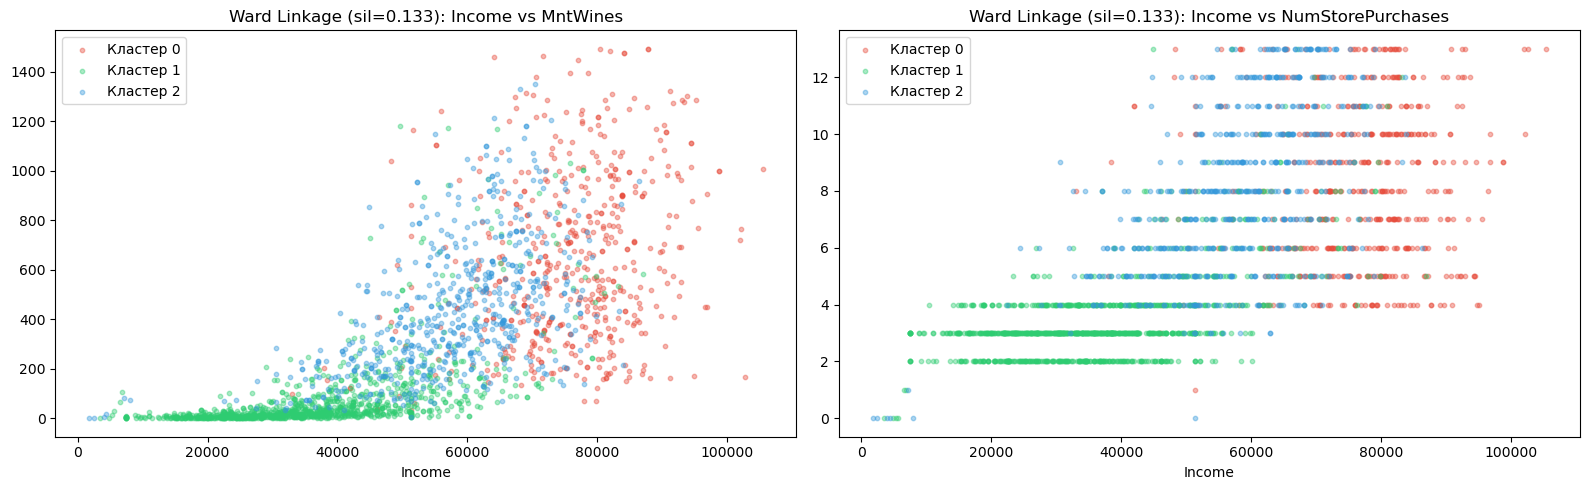

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

for cid in range(3):
    mask = df_clean['Cluster_Ward'] == cid
    axes[0].scatter(df_clean.loc[mask, 'Income'], df_clean.loc[mask, 'MntWines'],
                    alpha=0.4, s=10, color=colors[cid], label=f'Кластер {cid}')
    axes[1].scatter(df_clean.loc[mask, 'Income'], df_clean.loc[mask, 'NumStorePurchases'],
                    alpha=0.4, s=10, color=colors[cid], label=f'Кластер {cid}')

axes[0].set_title(f'Ward Linkage (sil={sil_ward:.3f}): Income vs MntWines')
axes[1].set_title(f'Ward Linkage (sil={sil_ward:.3f}): Income vs NumStorePurchases')
for ax in axes:
    ax.set_xlabel('Income'); ax.legend()

plt.tight_layout()
plt.show()

Ward linkage дав збалансований розподіл по кластерах, на відміну від single linkage де всі точки падали в один кластер. силует невисокий, але кластеризація більш змістовна. ця кластеризація могла б бути корисною для сегментації клієнтів, але KMeans без масштабування показав кращий силует і більш чіткі кластери на візуалізації